Key Components to be fulfilled:  
1. Data Exploration: (Score : 2) 
● Explore the data, list down the unique values in each feature and find its length.  
● Perform the statistical analysis and renaming of the columns.  
2. Data Cleaning: (Score : 2)  
● Find the missing and inappropriate values, treat them appropriately.  
● Remove all duplicate rows.  
● Find the outliers.  
● Replace the value 0 in age as NaN Treat the null values in all columns using any 
measures(removing/ replace the values with mean/median/mode) . 
3. Data Analysis: (Score : 2)  
● Filter the data with age >40 and salary<5000 Plot the chart with age and salary 
Count the number of people from each place and represent it visually  
4. Data Encoding: (Score : 2)  
● Convert categorical variables into numerical representations using techniques 
such as one-hot encoding, label encoding, making them suitable for analysis by 
machine learning algorithms.  
5. Feature Scaling: (Score : 2)  
● After the process of encoding, perform the scaling of the features using 
standardscaler and minmaxscaler. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Employee.csv.crdownload")

In [5]:
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


1. Data Exploration: (Score : 2) 
● Explore the data, list down the unique values in each feature and find its length.  
● Perform the statistical analysis and renaming of the columns.  

In [8]:
df.shape

(148, 6)

In [9]:
df.columns

Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')

In [10]:
for col in df.columns:
    print("\nColumn:",col)
    print("Unique values:",df[col].unique())
    print("Number of unique values:",df[col].nunique())


Column: Company
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Number of unique values: 6

Column: Age
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Number of unique values: 29

Column: Salary
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Number of unique values: 40

Column: Place
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Number of unique values: 11

Column: Country
Unique values: ['India']
Number of unique values: 1

Column: Gender
Unique values: [0 1]
Number of unique values: 2


In [12]:
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [15]:
df.columns

Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')

In [16]:
df.rename(columns={
    "Company":"company",
    "Age":"age",
    "Salary":"salary",
    "Place":"place",
    "Country":"country",
    "Gender":"gender"},inplace=True) #inplcae orginal df ilum change avan

In [17]:
df

,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


2. Data Cleaning: (Score : 2)  
● Find the missing and inappropriate values, treat them appropriately.  
● Remove all duplicate rows.  
● Find the outliers.
● Replace the value 0 in age as NaN Treat the null values in all columns using any 
measures(removing/ replace the values with mean/median/mode) . 

In [19]:
df.isnull().sum()

company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64

In [20]:
df["age"].mean()

np.float64(30.484615384615385)

In [21]:
df["age"].median()

32.5

In [22]:
df["salary"].mean()

np.float64(5312.467741935484)

In [23]:
df["salary"].median()


5000.0

In [48]:
df["age"]=df["age"].replace(0,np.nan)


In [50]:
df.isnull().sum()

company          0
age              0
salary           0
place            0
country          0
gender           0
place_encoded    0
dtype: int64

In [51]:
df["age"]=df["age"].fillna(df["age"].median())
df["salary"]=df["salary"].fillna(df["salary"].median()) 

In [52]:
df["company"].mode()[0]

'TCS'

In [53]:
df["place"].mode()[0]

'Mumbai'

In [54]:
df["company"]=df["company"].fillna(df["company"].mode()[0])
df["place"]=df["place"].fillna(df["place"].mode()[0])

In [55]:
df.isnull().sum()

company          0
age              0
salary           0
place            0
country          0
gender           0
place_encoded    0
dtype: int64

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df.drop_duplicates(inplace=True)

In [58]:
df.duplicated().sum()

np.int64(0)

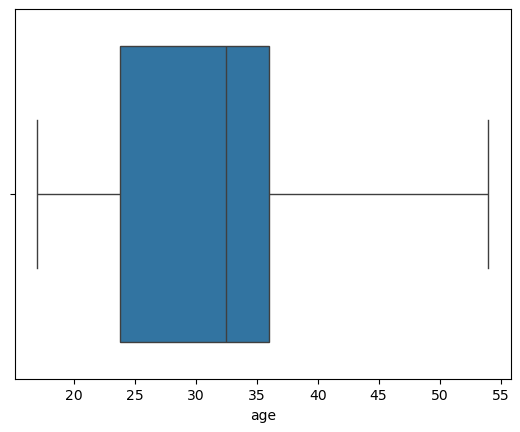

In [59]:
sns.boxplot(x=df["age"])
plt.show()

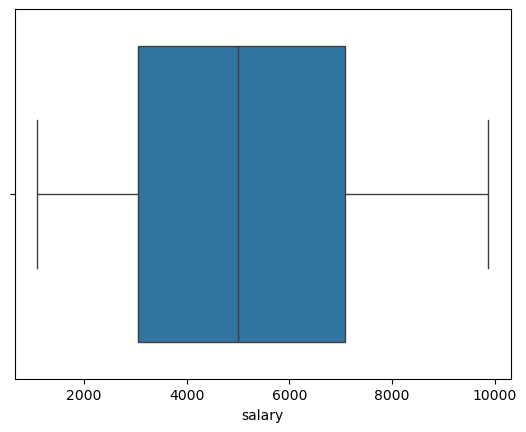

In [36]:
sns.boxplot(x=df["salary"])
plt.show()

3. Data Analysis: (Score : 2)  
● Filter the data with age >40 and salary<5000 Plot the chart with age and salary 
Count the number of people from each place and represent it visually  

In [37]:
filtered_df=df[(df["age"]>40)&(df["salary"]<5000)]
filtered_df

,company,age,salary,place,country,gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
86,Infosys,41.0,3000.0,Delhi,India,0
93,Infosys,54.0,3184.0,Mumbai,India,0
104,Infosys,44.0,4034.0,Delhi,India,0


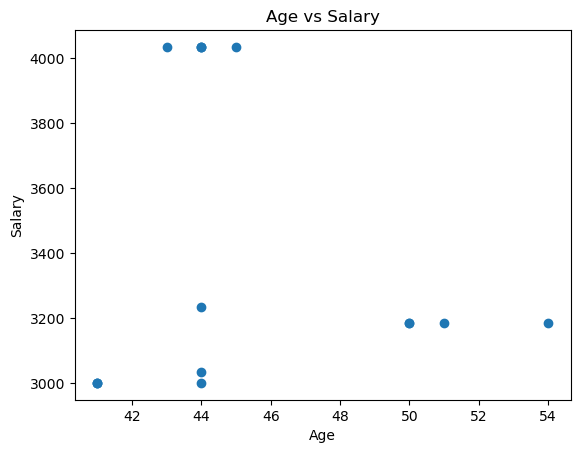

In [39]:
plt.scatter(filtered_df["age"], filtered_df["salary"])
 
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
 
plt.show()

In [42]:
place_count=df["place"].value_counts()
print(place_count)

place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


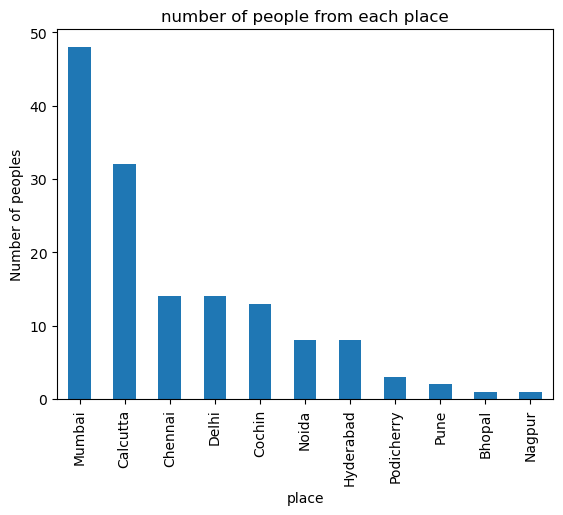

In [43]:
place_count.plot(kind="bar")
plt.xlabel("place")
plt.ylabel("Number of peoples")
plt.title("number of people from each place")
plt.show()

4. Data Encoding: (Score : 2)  
● Convert categorical variables into numerical representations using techniques 
such as one-hot encoding, label encoding, making them suitable for analysis by 
machine learning algorithms.  

In [44]:
df_onehot = pd.get_dummies(
    df,
    columns=["company", "place", "country"]
) 
df_onehot.head() # one hot vecha company epo tcs anel tcs il indel 1 allel 0

,age,salary,gender,company_CTS,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Bhopal,...,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,country_India
0,20.0,5000.0,0,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,True
1,30.0,5000.0,0,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,35.0,2300.0,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
3,40.0,3000.0,0,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,23.0,4000.0,0,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True


In [45]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["place_encoded"] = le.fit_transform(df["place"])
df[["place", "place_encoded"]].head()#label vecha epo order number koduka example chennai 2 enna number so evdeoke chennai indo avde 2 avum

,place,place_encoded
0,Chennai,2
1,Mumbai,6
2,Calcutta,1
3,Delhi,4
4,Mumbai,6


5. Feature Scaling: (Score : 2)  
● After the process of encoding, perform the scaling of the features using 
standardscaler and minmaxscaler. 

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_standard = df_onehot.copy()
df_standard[["age", "salary"]] = scaler.fit_transform(
    df_standard[["age", "salary"]]
) 
df_standard.head()
 

,age,salary,gender,company_CTS,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Bhopal,...,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,country_India
0,-1.033034,-0.100827,0,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,True
1,-0.073002,-0.100827,0,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.407013,-1.243735,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.887029,-0.947426,0,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,-0.745024,-0.524127,0,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True


In [47]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_minmax = df_onehot.copy()
df_minmax[["age", "salary"]] = scaler.fit_transform(
    df_minmax[["age", "salary"]]
)
df_minmax.head()

,age,salary,gender,company_CTS,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Bhopal,...,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,country_India
0,0.370370,0.445089,0,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,True
1,0.555556,0.445089,0,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.648148,0.137817,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.740741,0.217480,0,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,0.425926,0.331285,0,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
